# 准备数据

使用孙衍刚的数据训练一下模型

In [2]:
%reset -f
import scanpy as sc

# 4m 5.3s
sc_adata = sc.read("mouseBrain_RNA_counts.h5ad")
# sp_adata = sc.read("/media/williamhan/4E44841544840247/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
sp_adata = sc.read("D:/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
sc_adata, sp_adata

(AnnData object with n_obs × n_vars = 378287 × 52198
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'libId', 'percent.mt', 'percent.ribo', 'countFeatureRatio', 'sampleId', 'batchId', 'maxPredClass', 'sampleRegion1', 'sampleRegion2', 'sampleRegion3', 'Cell_cluster', 'Cell_group', 'Description', 'Cell_subclass', 'Cell_class', 'Color', 'ident'
     uns: 'X_name'
     obsm: 'HARMONY', 'PCA', 'UMAP'
     layers: 'logcounts',
 AnnData object with n_obs × n_vars = 497563 × 19781
     obs: 'library', 'group', 'sample', 'accession', 'condition', 'time', 'batch', 'dnbCount', 'x', 'y', 'area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'passing_mt', 'passing_ngenes', '_scvi_batch', '_scvi_labels'
     var: 'mt', 'ribo', 'hb', 'n_cel

In [ ]:
sel_col = ["maxPredClass", "Cell_cluster", "Cell_group", "Description", "Cell_subclass", "Cell_class", "Color", "ident"]
sc_adata.obs.loc[:, sel_col].drop_duplicates()

In [ ]:
sc_adata.obs.loc[:, ["Cell_group", "Cell_subclass", "Cell_class",]].drop_duplicates().to_csv("Comparison_table.csv")

In [ ]:
for key in ["logcounts"]:
    if key in sc_adata.layers:
        del sc_adata.layers[key]

# uns 和 obsm 是整个容器，不建议直接 del sc_adata.uns / del sc_adata.obsm
# 更稳妥是清空里面的内容
sc_adata.uns.clear()
sc_adata.obsm.clear()

# celltype 必须是 categorical
sc_adata.obs["celltype"] = sc_adata.obs["Cell_group"].astype("category")
# 必须有一列是 celltype
sc_adata.obs = sc_adata.obs.loc[:, ["celltype"]]
sc_adata

In [ ]:
import numpy as np

# 1. 确保基因名唯一
sp_adata.var_names_make_unique()
sc_adata.var_names_make_unique()

# 2. 取交集
common_genes = sp_adata.var_names.intersection(sc_adata.var_names)

print(f"sp_adata genes: {sp_adata.n_vars}")
print(f"sc_adata genes: {sc_adata.n_vars}")
print(f"common genes: {len(common_genes)}")

# 3. 按同一组基因、同一顺序切片
sp_adata = sp_adata[:, common_genes].copy()
sc_adata = sc_adata[:, common_genes].copy()

# 4. 确认顺序一致
assert np.array_equal(sp_adata.var_names, sc_adata.var_names)

sc_adata, sp_adata

In [ ]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
import gc

# 假设对象叫 sp_adata

# 1. 保留 obs_names 和 var_names
obs_names = sp_adata.obs_names.copy()
var_names = sp_adata.var_names.copy()

# 2. 保留 spatial
if "spatial" not in sp_adata.obsm:
    raise KeyError("sp_adata.obsm 中没有 'spatial'")

spatial = sp_adata.obsm["spatial"].astype(np.float32)

# 3. 保留 X，并压缩 dtype
if sp.issparse(sp_adata.X):
    sp_adata.X = sp_adata.X.tocsr()
    sp_adata.X.data = sp_adata.X.data.astype(np.float32)
else:
    sp_adata.X = sp_adata.X.astype(np.float32)

# 4. 全部清空 obs / var 注释，只保留 index
sp_adata.obs = pd.DataFrame(index=obs_names)
sp_adata.var = pd.DataFrame(index=var_names)

# 5. 只放回 spatial
sp_adata.obsm.clear()
sp_adata.obsm["spatial"] = spatial

# 6. 其他全部清空
sp_adata.layers.clear()
sp_adata.obsp.clear()
sp_adata.varm.clear()
sp_adata.uns.clear()
sp_adata.raw = None

gc.collect()

sp_adata

In [ ]:
sc_adata.write("reference_sc_syg.h5ad")
sp_adata.write("inference_sp.h5ad")

# 预训练

In [1]:
%reset -f
import gc
import torch
import scanpy as sc
from spatialid import Transfer

tr = Transfer(
    single_data="/mnt/d/Python/bioinformatics_project/MCAO20250929/data/spatialid/reference_sc_syg.h5ad",
    spatial_data="/mnt/d/Python/bioinformatics_project/MCAO20250929/data/spatialid/inference_sp.h5ad",
    output_path="./spatialid_output",
    device=0
)

tr.learn_sc(
    ann_key="Cell_group",
    marker_genes=None,
    batch_size=128,
    epoch=50
)

del tr
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Initializing...
Loading scRNA-seq Data...
Loading spRNA-seq Data...
All data loaded.
Prepare to train...
Training...


  2%|▏         | 1/50 [00:33<27:31, 33.71s/it]

  [2026-05-15 15:46:04] Epoch:   1 Loss: 0.73350, acc: 19.06%


  4%|▍         | 2/50 [01:05<26:12, 32.77s/it]

  [2026-05-15 15:46:36] Epoch:   2 Loss: 0.59878, acc: 33.01%


...

 98%|█████████▊| 49/50 [25:37<00:31, 31.27s/it]

  [2026-05-15 16:11:08] Epoch:  49 Loss: 0.36519, acc: 57.44%


100%|██████████| 50/50 [26:08<00:00, 31.37s/it]

  [2026-05-15 16:11:39] Epoch:  50 Loss: 0.36512, acc: 57.49%

 validation model: 
The checkpoint was saved: dict_keys(['model', 'marker_genes', 'batch_size', 'label_names'])



  [2026-05-15 16:12:05 total accuracy: 97.47%]


# 注释

In [ ]:
%reset -f
import gc
import torch
from spatialid import Transfer

tr = Transfer(
    single_data=None,   # 关键：第二步不要再读单细胞大文件
    spatial_data="inference_sp.h5ad",
    output_path="./spatialid_output",
    device=0
)

tr.sc2st("./spatialid_output/learn_sc_dnn.bgi")

tr.annotation(
    pca_dim=50,      # 先从 200 降到 50
    n_neigh=10,      # 先从 30 降到 10
    epochs=100,
    w_gae=0.1        # 降低图重构损失权重
)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# 可视化

In [ ]:
%reset -f
import squidpy as sq
import scanpy as sc

adata = sc.read("spatialid_output/annotation.h5ad")
# sp_adata = sc.read("/media/williamhan/4E44841544840247/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
sp_adata = sc.read("D:/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
adata, sp_adata

In [ ]:
import pandas as pd

# 要同步的列
cols = ["pseudo_class", "celltype_pred"]

# 检查列是否存在
missing_cols = [c for c in cols if c not in adata.obs.columns]
if missing_cols:
    raise KeyError(f"adata.obs 中缺少这些列: {missing_cols}")

# 检查 obs index 是否唯一
if not adata.obs_names.is_unique:
    raise ValueError("adata.obs_names 不唯一，不能安全按 index 同步")

if not sp_adata.obs_names.is_unique:
    raise ValueError("sp_adata.obs_names 不唯一，不能安全按 index 同步")

# 查看匹配情况
common_idx = sp_adata.obs_names.intersection(adata.obs_names)
print(f"sp_adata cells: {sp_adata.n_obs}")
print(f"adata cells: {adata.n_obs}")
print(f"matched cells: {len(common_idx)}")
print(f"unmatched in sp_adata: {sp_adata.n_obs - len(common_idx)}")

# 按 sp_adata.obs_names 顺序重排 adata.obs 中对应列
mapped = adata.obs[cols].reindex(sp_adata.obs_names)

# 同步到 sp_adata.obs
for c in cols:
    sp_adata.obs[c] = mapped[c]

# 可选：检查同步后的缺失
print(sp_adata.obs[cols].isna().sum())

del adata

In [ ]:
# 保存
sq.pl.spatial_scatter(sp_adata, color="celltype_pred", library_key="library", library_id=["sham", "MCAO_1d", "MCAO_3d", "MCAO_14d",], img=False, size=50)
sq.pl.spatial_scatter(sp_adata, color="pseudo_class", library_key="library", library_id=["sham", "MCAO_1d", "MCAO_3d", "MCAO_14d",], img=False, size=50)
sp_adata.write("D:/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_annotated.h5ad")

# 训练过程评估

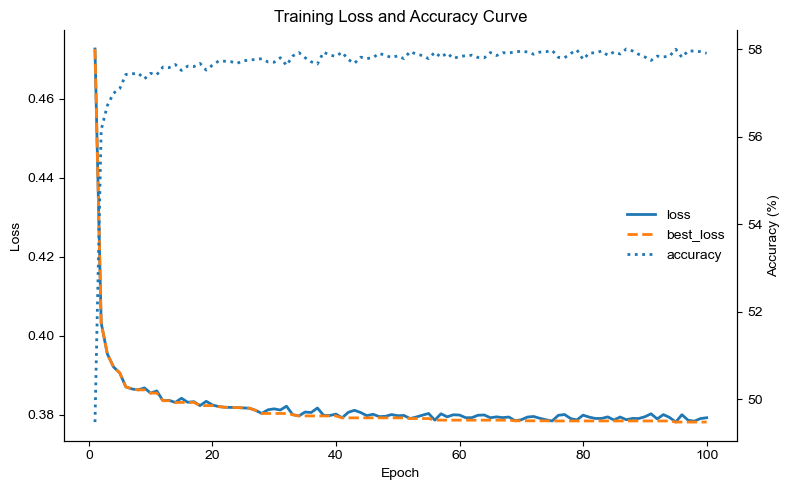

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:/Python/SpatialID/spatialid_output/train_history.csv")
df["time"] = pd.to_datetime(df["time"])

plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax1 = plt.subplots(figsize=(8, 5))

# 左轴：loss
ax1.plot(df["epoch"], df["loss"], label="loss", linewidth=2)
ax1.plot(df["epoch"], df["best_loss"], label="best_loss", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# 右轴：accuracy
ax2 = ax1.twinx()
ax2.plot(df["epoch"], df["acc"], label="accuracy", linewidth=2, linestyle=":")
ax2.set_ylabel("Accuracy (%)")

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, loc="center right")

ax1.set_title("Training Loss and Accuracy Curve")

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()